# Softmax Regression

Suppose you want to write a program
that will classify handwritten drawing of
digits into their appropriate category: **0**, **1**, **2**, ..., **9**.
You could, think hard about the nature of
digits, try to determine the logic of what
indicates what kind of digit, and write a
program to codify this logic. Or you could take advantage of the **statistics** of the data, e.g. pixel intensity in a 28 x 28 grid, as discriminative features of each instance.
For this task we will use the MNIST dataset:

![](img/02-1.png){width=100%}

**ML approach.** Collect a training set of images with known labels
and feed these into a machine learning algorithm, which, if done well, will automatically produce a [program]{.mark} that solves this task. The generated program contains an unusually large amount of [magic numbers](https://en.wikipedia.org/wiki/Magic_number_(programming)) that will be used to determine the output class:

![](./img/02-2.png){width=100%}

:::{.callout-note}
Notice that the latter input is different from training data. In practice, we want the models to perform well on unlabeled data.
In other words, the model **generalizes**.
:::

The learning algorithm that materializes the program consist of three elements:

| Element | Object | Description |
| :--: | :--: | :-- |
| **Hypothesis class**  | $\mathcal{H}$ <br> <img width=500/> | Defines the [program structure]{.underline} from inputs to outputs. In practical terms, it corresponds to the choice of **model architecture** and **hyperparameters** (e.g. linear model or tree-based models with depth 20). Formally, $\mathcal{H} = \{ h_\Theta\colon \mathcal{X} \to \mathcal{Y} \mid \Theta \in \mathbb{R}^M \}$ consisting of parametric functions. |
| **Loss function** | $\mathcal{L}, \ell$ | Specifies how well a given **hypothesis** $h_\Theta$ (i.e. a choice of parameters) performs on the task of interest. The loss is generally expressed in terms of a pointwise **loss function** $\ell$ such that: $$\mathcal{L}_{\mathcal{D}}(\Theta) = \frac{1}{N}\sum_{i=1}^N \ell(h_\Theta(\mathbf{x}_i), y_i)$$ where $\ell \geq 0$ and $\ell \to 0$ whenever the predictions are accurate, and $\ell \to \infty$ as the predictions become increasingly worse. |
| **Optimizer** | e.g.<br> [`torch.optim.*`](https://docs.pytorch.org/docs/stable/optim.html#how-to-use-an-optimizer), [`LRScheduler`](https://docs.pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) | The optimizer handles **state** and the **algorithm** required to find optimal parameters that minimize the training loss. For deep learning, this is typically an iterative approach via SGD and its variants: $$\Theta_{t+1}, \Lambda_{t+1} = \mathscr{G}(\Theta_t, \Lambda_{t})$$ where $\Lambda_t$ is the current state. The goal of training is for the parameters to converge to some $\hat{\Theta}$ that approximately minimizes the training loss. That is, $\hat{\Theta} \approx {\text{argmin}}_{\Theta} \; \mathcal{L}_\mathcal{D}(\Theta).$|

**Multi-class classification.** In this setting the training dataset $\mathcal{D}$ consists of input-output pairs
$\mathcal{D} = (\mathbf{x}_i, y_i)_{i=1}^N$ 
where $\mathbf{x}_i \in \mathbb{R}^d$ with $d$ is the input dimensionality and $y_i \in [1, K] \subset \mathbb{Z}$ where $K$ is the number of classes and $N = | \mathcal{D} |$ is the size of the dataset. Then, a **hypothesis function** $h \colon \; \mathbb{R}^d \to \mathbb{R}^K$ maps input vectors $\mathbf{x}$ to $K$-dimensional vectors.
The output $h_j(\mathbf{x})$ indicates some measure of "belief" in how much likely the label is to be class $j$. That is, the most likely class for an input $\mathbf{x}$ is predicted as the coordinate $\hat{j} = \text{argmax}_j \; h_j(\mathbf{x})$.

**Example.** For MNIST, $d = 28 \times 28 = 784$, $K = 10$ and $N = 60,000.$

## Linear hypothesis class

A **linear hypothesis function** has matrix multiplication as core operation:
$h_\Theta(\mathbf{x}) = \Theta^\top \mathbf{x}$ for parameters $\Theta \in \mathbb{R}^{d \times K}.$ In practice, we usually write this using matrix-batch notation since we process inputs in parallel as a matrix:

$$
h_\Theta(\mathbf{X}) =  \underbrace{\mathbf{X}}_{\mathbb{R}^{M \times d}} \; \underbrace{\Theta}_{\mathbb{R}^{d \times K}} \in \mathbb{R}^{M \times K}
$$

where the inputs are laid out as row vectors inside the matrix:

$$
\begin{equation}
\mathbf{X}=\left[\begin{array}{c}
-\, \mathbf{x}^{(1)\top}- \\
\vdots \\
-\, \mathbf{x}^{(M)\top}-
\end{array}\right] \in \mathbb{R}^{M \times d}
\end{equation}.
$$


**Remark.** Geometrically each $\Theta_j = \Theta_{[:, j]} \in \mathbb{R}^d$ defines a separating hyperplane for class $j \in [K].$ So a linear hypothesis class is able to learn to separate linearly separable data points in $\mathbb{R}^d$ using $K$ separating hyperplanes by assigning a score $s_j = \Theta_j^\top \mathbf{x} \in \mathbb{R}$ proportional to its weighted distance from the hyperplane, and the "weight" of that hyperplane $\lVert\Theta_j\rVert.$

## Softmax and cross-entropy

The simplest loss is just the **zero-one loss**: 
$\ell = 0$ if $\operatorname{argmax}_i h_i(\mathbf{x}) = y$, otherwise $\ell = 1.$
This is just the classification error. Unfortunately, the error is unsuitable for optimization, simply because it is not differentiable. That is, we can smoothly adjust the parameters without seeing a change in $\ell$, or it transitions abruptly from $0$ to $1.$

Instead, we look at the probabilities assigned by the model to each class. To do this, we have to convert the class scores to probabilities exponentiating and
normalizing its entries (i.e. making $\sum_j p = 1$ s.t. $p_j \geq 0$). Class scores $h_j(\mathbf{x}) = \Theta_j^\top \mathbf{x}$ are exponentiated before normalizing:

$$
p_j = \frac{\exp(h_j(\mathbf{x}))}{\sum_l \exp(h_l(\mathbf{x}))} \eqqcolon \text{Softmax} (h(\mathbf{x}))_j.
$$

We can let $\hat{\mathbf{y}}$ be equal to $\mathbf{p} = \text{Softmax} (h(\mathbf{x}))$ since the softmax
approximates the one-hot vector $\mathbf{y}$ of the target label $y$ (see remark below). Then, what is left 
is to define a loss function that captures the difference between the model probability vector and the true
one. For this, we use the **cross-entropy loss** given by the negative log of the probability of the true 
class $y$:

$$
\boxed{
    \begin{aligned}
    \ell_{\text{CE}}(h(\mathbf{x}), y) 
    &= -\log \hat{\mathbf{y}} \odot \mathbf{y}\\[0.8em]
    &= -\log \text{Softmax} (h(\mathbf{x}))_y \\
    &= -h_y(\mathbf{x})+\log \sum_{j=1}^K \exp \left(h_j(\mathbf{x})\right).
    \end{aligned}
}
$$

Here $p_y = 1$ implies $\ell = -\log 1 = 0$ while $p_y = 0$ implies $-\log 0 = +\infty.$ Hence, the model is penalized the more it becomes unconfident in the true class.
Note taking the negative log of the true class suffices to penalize high score in the other classes since we have the constraint $\sum p_j = 1.$ Also, looking at the gradient, the logarithm has the nice property that it does not saturate as it approaches perfect prediction, and it explodes with really bad predictions:

$$\frac{\partial\ell}{\partial p_y} = -\frac{1}{p_y}.$$


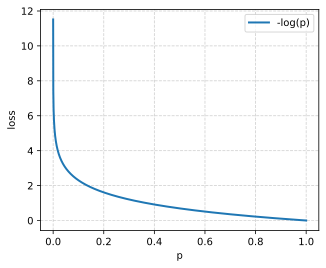

In [1]:
#| code-fold: true
%config InlineBackend.figure_formats = ['svg'] 
import matplotlib.pyplot as plt
import numpy as np

eps = 1e-5
p = np.linspace(0 + eps, 1, 10000)
plt.figure(figsize=(5, 4))
plt.plot(p, -np.log(p), linewidth=2, label="-log(p)")
plt.grid(alpha=0.6, linestyle="dashed")
plt.xlabel("p"); plt.ylabel("loss")
plt.legend();

To further visualize the cross-entropy loss, let's incorporate this graph in the evaluation process. The **baseline loss** is given by $-\log 0.1 \approx 2.30$ assuming uniform prediction across 10 classes. Since the loss decrease more going from $p= 0.1$ to $0.2$ compared to $p = 0.5$ to $0.6$ for the true class, then the optimizer will focus on examples with bad predictions during training. This is desirable behavior.

  0%|                                                                             | 0.00/9.91M [00:00<?, ?B/s]

  0%|▏                                                                    | 32.8k/9.91M [00:00<01:06, 149kB/s]

  1%|▍                                                                    | 65.5k/9.91M [00:00<01:11, 137kB/s]

  2%|█▏                                                                    | 164k/9.91M [00:00<00:38, 253kB/s]

  3%|██▎                                                                   | 328k/9.91M [00:00<00:23, 413kB/s]

...

 70%|███████████████████████████████████████████████▉                     | 1.15M/1.65M [00:01<00:00, 781kB/s]

 85%|██████████████████████████████████████████████████████████▉          | 1.41M/1.65M [00:02<00:00, 852kB/s]

100%|█████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 726kB/s]

  0%|                                                                             | 0.00/4.54k [00:00<?, ?B/s]

100%|████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 3.50MB/s]

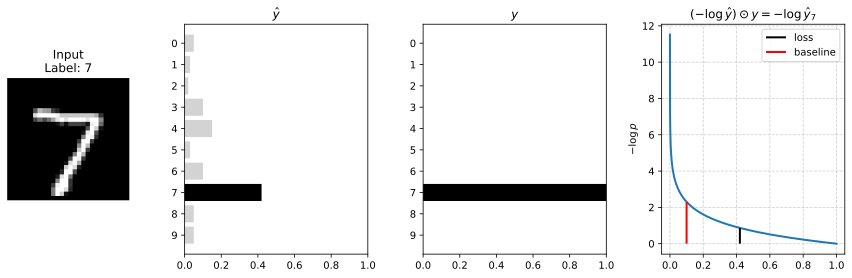

In [2]:
#| echo: false
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

# Load MNIST using PyTorch
transform = transforms.ToTensor()
mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
img, true_label = mnist[0]  # img is a tensor of shape [1, 28, 28]

# Dummy probability vectors
p1 = [0.05, 0.03, 0.02, 0.1, 0.15, 0.03, 0.1, 0.42, 0.05, 0.05]
p2 = -np.log(np.array(p1)) 
p3 = [0.] * 10
p3[7] = 1.0
labels = [str(i) for i in range(10)]

# Display the MNIST image
fig, ax = plt.subplots(1, 4, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1.5, 1.5, 1.5]})
ax[0].imshow(img.squeeze(), cmap='gray')
ax[0].axis('off')
ax[0].set_title(f"Input\nLabel: {true_label}")

# Display probability vectors
ax[1].barh(labels, p1, color=["black" if i == 7 else "lightgray" for i in range(10)])
ax[1].set_title(r'$\hat{y}$')
ax[1].invert_yaxis()
ax[1].set_xlim(0, 1)

ax[3].plot(p, -np.log(p), linewidth=2)
x = p1[7]
y = -np.log(p1[7])
baseline = -np.log(0.1)
ax[3].vlines(x, 0, y, color='black', linewidth=2, label="loss")
ax[3].vlines(0.1, 0, baseline, color='red', linewidth=2, label="baseline")
ax[3].legend()
ax[3].grid(alpha=0.6, linestyle="dashed")
ax[3].set_title(r'$(-\log \hat{y}) \odot y = -\log \hat{y}_7$')
ax[3].set_ylabel(r"$-\log p$")


ax[2].barh(labels, p3, color="black")
ax[2].set_title(r'$y$')
ax[2].set_xlim(0, 1)
ax[2].invert_yaxis()

plt.tight_layout()

**Remark.** The softmax can be made to be numerically stable. To see this, notice that 

$$
p_j = \frac{\exp(\Delta h_j(\mathbf{x}))}{\sum_l \exp(\Delta h_l(\mathbf{x}))}
$$

where $\Delta h_l(\mathbf{x}) = h_l(\mathbf{x}) - \max_{m} h_m(\mathbf{x}).$ Thus log-softmax becomes $\log (1 + \sum a_j)$ where $0 < a_j \leq 1$, preventing both underflow and overflow. Moreover, it shows that the individual scores scale exponentially with the difference from the largest score. Hence, this transformation is sometimes called soft-*arg*max since it tends to pick out the largest entry.

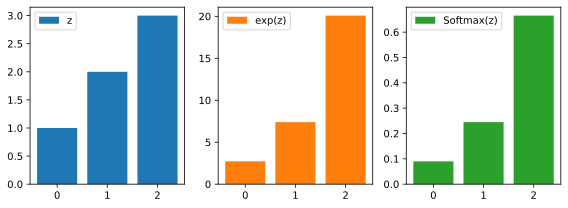

In [3]:
#| code-fold: true
import torch
z = torch.tensor([1, 2, 3]).float()
fig, ax = plt.subplots(1, 3, figsize=(8, 3))
ax[0].bar(range(3), z.numpy(), label="z")
ax[1].bar(range(3), z.exp().numpy(), color="C1", label="exp(z)")
ax[2].bar(range(3), z.exp().numpy() / z.exp().numpy().sum(), color="C2", label="Softmax(z)")
ax[0].legend(); ax[1].legend(); ax[2].legend();
fig.tight_layout()

## Gradient-based learning

The third ingredient of a learning algorithm is a method for solving the
associated optimization problem, i.e. the problem of minimizing the average loss
on the training set:

$$
\hat{\Theta} = \underset{\Theta}{\operatorname{min}} \frac{1}{N} \sum_{i=1}^N \ell_{\text{CE}} (h_\Theta(\mathbf{x}_i), y_i)
$$

How do we find an optimal set of parameters $\hat{\Theta}$? It turns out that an iterative approach is the most practical.

### Gradient Descent

For a matrix-input, scalar-output function $f\colon \mathbb{R}^{d \times k} \to \mathbb{R}$ the **gradient** $\nabla_\Theta f(\Theta)$ is defined as the matrix of partial derivatives:

$$
\nabla_\Theta f(\Theta) =\left[\begin{array}{ccc}
\frac{\partial f(\Theta)}{\partial \Theta_{11}} & \cdots & \frac{\partial f(\Theta)}{\partial \Theta_{1 k}} \\
\vdots & \ddots & \vdots \\
\frac{\partial f(\Theta)}{\partial \Theta_{d 1}} & \cdots & \frac{\partial f(\Theta)}{\partial \Theta_{d k}}
\end{array}\right] \in \mathbb{R}^{d \times k}
$$

**NOTE:** $\nabla_\Theta f$ always has the same shape as $\Theta$ when $f$ is a scalar.

From the multivariate Taylor expansion,

$$
f(\Theta + \Delta \Theta) \approx f(\Theta) + \nabla_\Theta f(\Theta) \cdot \Delta\Theta + \mathcal{O}(\Delta\Theta^2).
$$

So that the gradient locally points in the direction that most increases $f$, i.e. to first order. Hence, to minimize $f$, we iteratively update the weight by $-\nabla_\Theta f$ at each point in the surface defined by $f$:

$$
\Theta_{t + 1} = \Theta_t - \alpha \cdot \nabla_\Theta f (\Theta_t)
$$

where $\alpha > 0$ is called the **learning rate**. GD is naturally sensitive to the scale of the learning rate and the initial point $\Theta_0.$

![](./img/02-3.png){width=100%}

### Stochastic Gradient Descent (SGD)

In practice, computing the gradient over the entire dataset for a single parameter update is often prohibitively expensive, especially when $N$ is large (typical in deep learning). Instead, we perform many gradient steps, each using a randomly sampled subset $\mathcal{B} \subset \mathcal{D}$ called a **mini-batch**, where the **batch size** $B = |\mathcal{B}| \ll N$. At each training step:

1. Randomly sample $\mathcal{B} \subset \mathcal{D}$ so that we get $\mathbf{X}_\mathcal{B} \in \mathbb{R}^{B \times d}$ and $\mathbf{Y}_{\mathcal{B}} \in [K]^B.$

2. Update parameters: 
$$
\begin{aligned}\Theta_{t + 1}
= \Theta_t - 
\frac{\alpha}{B} \, 
\sum_{b \in I_\mathcal{B}} 
\nabla_\Theta \ell 
(h_{\Theta_t}(\mathbf{x}_b), y_b).
\end{aligned}
$$

It follows that the sample dataset varies at each training step. Unlike the previous case where $\mathcal{D}$ is fixed. This mechanism of SGD reduces overfitting by **implicit regularization** of the gradient, i.e. adding noise in the training process.

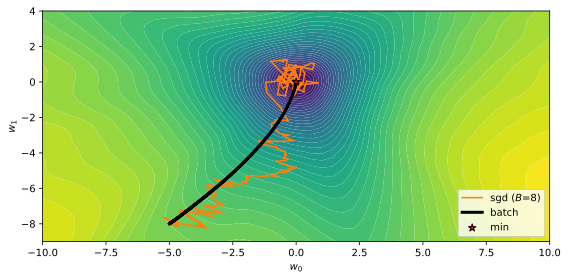

In [4]:
#| code-fold: true
#| echo: false
%config InlineBackend.figure_formats = ["svg"] 
import warnings
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
warnings.filterwarnings("ignore")


def plot_contourf(ax, f, title="", levels=20, x_min=-5, x_max=5, y_min=-5, y_max=5, N=50):
    x = np.linspace(x_min, x_max, N)
    y = np.linspace(y_min, y_max, N)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(N):
        for j in range(N):
            Z[i, j] = f(X[i, j], Y[i, j])

    ax.contourf(X, Y, Z, levels=levels, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(r"$w_0$")
    ax.set_ylabel(r"$w_1$")

def plot_trajectory(ax, w, color, alpha=1.0, label=None, **kw):
    for t in range(1, len(w)):
        if t == 1:
            ax.plot(*zip(w[t - 1], w[t]), color=color, alpha=alpha, label=label, **kw)
        else:
            ax.plot(*zip(w[t - 1], w[t]), color=color, alpha=alpha, **kw)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def loss(w0, w1, X, y):
    """non-convex loss: MSE between squared sigmoid outputs and targets"""
    w = np.array([w0, w1])
    p = sigmoid(X @ w) ** 2
    return ((p - y) ** 2).mean()

def grad(w, X, y):
    z = X @ w
    s = sigmoid(z)
    p = s ** 2
    delta = (p - y) * 2 * s * (1 - s) * 2  # chain rule
    g = (delta.reshape(-1, 1) * X).mean(axis=0)
    return g

def sgd(w0, X, y, eta=0.1, steps=10, B=32):
    w = np.zeros([steps, 2])
    w[0, :] = w0
    for j in range(1, steps):
        batch = np.random.choice(np.arange(len(X)), size=(B,), replace=False)
        u = w[j - 1, :]
        w[j, :] = u - eta * grad(u, X[batch], y[batch])
    return w
    

# Generate data
np.random.seed(1)
n = 1000
X = np.random.randn(n, 2)
y = np.random.randint(0, 2, size=n)

w_init = [-5, -8]
w_step = lambda B: sgd(w_init, X, y, eta=2, steps=300, B=B)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 4), layout="constrained")
Bs = [8, len(X)]
colors= ["C1", "black"]
plot_contourf(ax, partial(loss, X=X, y=y), title="", levels=50, x_min=-10, x_max=10, y_min=-9, y_max=4)
plot_trajectory(ax, w_step(Bs[0]), color=colors[0], label=f"sgd ($B$={Bs[0]})", linewidth=1.5)
plot_trajectory(ax, w_step(Bs[1]), color=colors[1], label="batch", linewidth=3)
ax.scatter([0], [0], marker="*", color="red", label="min", edgecolor="black", s=60, zorder=3)
ax.legend(loc="lower right")
fig.tight_layout()

The total number of SGD steps scales is roughly $k = \frac{Nm}{B}$ where $m$ is the number of **epochs** (i.e. a full pass through the dataset, so that $m$ epochs means each data point is encountered by the network $m$ times) with a **convergence rate** of $\mathcal{O}({1}/{\sqrt{k}})$ [@bottou2008tradeoffs]. Since each step in SGD is cheap, in practice SGD often reaches good enough minima faster in wall-clock time despite slower theoretical rate due to noisy gradients (@fig-sgd-surface-convergence).

![**SGD convergence to the minimum.** Although each step is only an approximation, the updates generally move in the correct direction, allowing the optimizer to converge despite the noise. Trading precision for computational efficiency is effective when training large neural networks. In future discussions, we will see that network's high capacity and **over-parameterization** make it robust to noisy updates. Here consistent statistical perturbation gradually organizes the high-dimensional internal representations to separate the data.](./img/01-sgd-surface-convergence.png){#fig-sgd-surface-convergence}

### Gradient of cross-entropy

How do we actually compute $\mathcal{L}_{\text{CE}}$? 
This can be done using the chain rule and tracking functional dependencies. Recall:

$$
\ell_{\text{CE}}(h_\Theta(\mathbf{x}), y) = -h_\Theta(\mathbf{x})_y + \log \sum_{j=1}^K \exp \left(h_\Theta(\mathbf{x})_j\right).
$$

Let's start by deriving the gradient of the softmax loss itself. For a vector $\mathbf{h} \in \mathbb{R}^K$:

$$
\frac{\partial \ell_{\text{CE}}}{\partial h_j} = - \delta_{yj} + \frac{\exp h_j}{\sum_{l=1}^K \exp h_l} = - \delta_{yj} + p_j.
$$

In vector form, $\nabla_{\mathbf{h}} \ell_{\text{CE}} = \mathbf{p} - \mathbf{y}$ where $\mathbf{y}$ is a one-hot vector with 1 on index $y.$
Next, to calculate the derivative with respect to $\Theta$, we use the chain rule:

$$
\frac{\partial \ell_{\text{CE}}}{\partial \Theta_{ul}} =  \frac{\partial \ell_{\text{CE}}}{\partial h_j} \frac{{\partial h_j}}{\partial \Theta_{ul}} = \underbrace{(p_l - \delta_{yl})}_{K-\text{dim}} \; \underbrace{\vphantom{(}x_u}_{d-\text{dim}}.
$$

For the dimensions to make sense, $\frac{\partial \ell_{\text{CE}}}{\partial \Theta} = \mathbf{x}(\hat{\mathbf{y}} - \mathbf{y})^\top$ in matrix form. Recall that our vectors are column vectors and $\hat{\mathbf{y}} = \mathbf{p}.$ Here the product reverses since we traverse the dependence backwards from the loss. 

**Batch form.** The same process works for a batch of inputs, except that we have an additional batch index which we sum over since $\ell$ depends on all input instances. The contribution of each input is matched and aggregated using matrix multiplication:

$$
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial \Theta} = \frac{1}{B}\,\underbrace{\vphantom{(}\mathbf{X}^\top}_{d \times M} \;\; \underbrace{(\hat{\mathbf{Y}} - \mathbf{Y})}_{M \times K}.
$$

Here the transposes switched since $\mathbf{X}$ is constructed such that it has rows of $\mathbf{x}^\top,$ hence we internally get a double transpose. Putting it all together, we can write the SGD update rule for softmax regression as follows:

$$
\Theta_{t + 1} = \Theta_t - \frac{\alpha}{B} \; \mathbf{X}^\top (\hat{\mathbf{Y}} - \mathbf{Y}).
$$

Here we have $\frac{1}{B}$ since $\mathcal{L} = \frac{1}{B}\sum_b { \ell}_b.$ Also it makes sense to scale down since the sum grows with batch size $B.$ Finally, notice that the step size becomes smaller as $\| \hat{\mathbf{Y}} - \mathbf{Y} \| \to 0.$ To recap, we have the following equations:

$$
\boxed{
\begin{aligned}
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial \mathbf{H}} &= \frac{1}{B}  (\hat{\mathbf{Y}} - \mathbf{Y}) \\[0.75em]
\frac{\partial \mathcal{L}_{\text{CE}}}{\partial \Theta} &= \frac{1}{B} \mathbf{X}^\top  (\hat{\mathbf{Y}} - \mathbf{Y}) \\[0.60em]
\Theta_{t + 1} &= \Theta_t - \frac{\alpha}{B} \, \mathbf{X}^\top (\hat{\mathbf{Y}} - \mathbf{Y})
\end{aligned}
}
$$

## Code: Softmax Regression

**Data.** Since shuffling a large dataset at each training step is expensive, in practice, we shuffle it *once* and then iteratively draw $B$-sized slices of the data at each step — effectively sampling without replacement. After each epoch, we reshuffle the dataset for the next one. In PyTorch, this procedure is handled by the [`DataLoader` object](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler):

In [5]:
from torch.utils.data import DataLoader

NUM_EPOCHS = 2
x = torch.arange(10)
train_loader = DataLoader(x, batch_size=3, shuffle=True, drop_last=True)

for e in range(NUM_EPOCHS):
    for batch in train_loader:
        print(batch.numpy())
    print()

[4 0 9]
[5 2 6]
[7 8 3]

[8 4 0]
[3 7 1]
[6 2 9]



We will train a classification model based on the SGD update rule above:

In [6]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_dataset = datasets.MNIST('./data', train=True,  transform=transform)
valid_dataset = datasets.MNIST('./data', train=False, transform=transform)

**Model.** Defining the linear model:

In [7]:
import torch.nn as nn
model = nn.Linear(784, 10, bias=False)

:::{.callout-note}
The linear model can be extended to have a bias vector $\beta$, so that  $h_\Theta = \mathbf{X}\Theta + \beta$ where $\beta \in \mathbb{R}^K.$ But it turns out there is a "bias trick" in deep learning where an additional dimension containing only $+1$ is added so that the input becomes of shape $(N, d + 1).$ For simplicity, we stick with no bias.
:::

In [8]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.nn.functional as F

loss_train = []
NUM_EPOCHS = 5
B = 16
ALPHA = 0.01

@torch.no_grad()
def train_step(x, y):
    x = x.reshape(-1, 784)
    h = model(x)

    for theta in model.parameters():
        p = F.softmax(h, dim=1)
        e = F.one_hot(y, num_classes=10)
        g = x.T @ (p - e) / B

        theta -= ALPHA * g.T

    loss = -p[torch.arange(B), y].log().mean()
    return loss.item()


train_loader = DataLoader(train_dataset, batch_size=B, shuffle=True)  # SGD

for _ in tqdm(range(NUM_EPOCHS)):
    for x, y in train_loader:
        loss = train_step(x, y)
        loss_train.append(loss)

  0%|                                                                                   | 0/5 [00:00<?, ?it/s]

 20%|███████████████                                                            | 1/5 [00:04<00:16,  4.00s/it]

 40%|██████████████████████████████                                             | 2/5 [00:07<00:11,  3.86s/it]

 60%|█████████████████████████████████████████████                              | 3/5 [00:12<00:08,  4.42s/it]

 80%|████████████████████████████████████████████████████████████               | 4/5 [00:16<00:03,  3.97s/it]

100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:19<00:00,  3.70s/it]

100%|███████████████████████████████████████████████████████████████████████████| 5/5 [00:19<00:00,  3.87s/it]

**Remark.** Pytorch `nn.Linear` computes `x @ θ.T + b`. Hence, we take `g.T` before updating the parameter `θ`.

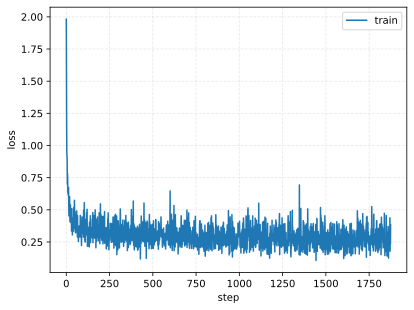

In [9]:
#| code-fold: true
plt.plot(np.array(loss_train).reshape(-1, 10).mean(1), label="train")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(alpha=0.3, linestyle="dashed")
plt.legend();

**Inference.** Sample label predictions:

In [10]:
dv = DataLoader(valid_dataset, batch_size=B, shuffle=False)
x, y = next(iter(dv))
out = model(x.reshape(B, -1)).argmax(1)
acc = (out == y).float()
print("Batch acc:", f"{acc.sum().int()}/{B}", f"({acc.mean().item() * 100}%)")

Batch acc: 15/16 (93.75%)


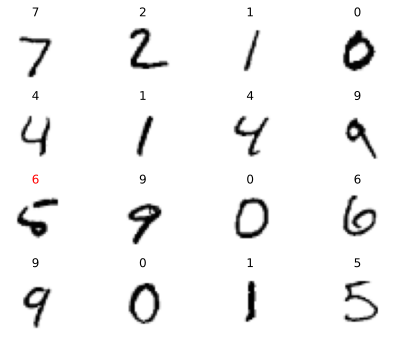

In [11]:
#| code-fold: true
fig, ax = plt.subplots(4, 4)
for i in range(B):
    a, b = divmod(i, 4)
    ax[a, b].imshow(x[i].reshape(28, 28), cmap="Greys")
    color = "black" if out[i] == y[i] else "red"
    ax[a, b].set_title(f"{out[i]}", color=color)
    ax[a, b].axis("off")

fig.tight_layout()

**Evals.** The practical goal of training is not actually to minimize $\mathcal{L}_\mathcal{D}(\Theta).$ But to minimize the loss for samples outside of the training dataset. That is, the model should be accurate on **test data**. If the model does not [overfit](https://en.wikipedia.org/wiki/Overfitting) and the test distribution does not drift too far from the training distribution, then we should be good. 

In [12]:
tot = 0
acc = 0
for x, y in dv:
    out = model(x.reshape(B, -1)).argmax(1)
    correct = (out == y).float()
    tot += len(y)
    acc += correct.sum()

print(f"Test acc: {acc / tot * 100:.2f}%")

Test acc: 92.22%


## Appendix: Model complexity


Since SGD relies on a stochastic process, the performance of the resulting trained model varies. How are we sure that we aren't just lucky for this particular run / random seed? In particular, we want to know what the **variance** of the performance of the trained model is over training runs, and whether there a way to control this. This issue is at the core of learning theory and precisely what the [Bias-Variance Tradeoff](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote12.html) addresses. 

In practice, the crucial parameter to control is **model complexity** (or **capacity**). This is a measure of how complicated a pattern or relationship a model architecture can express. Let $f$ be the true function that underlies the task. If model capacity is sufficiently large, the **model class** $\mathcal{F} = \{f_{\Theta} \mid \Theta \in \mathbb{R}^d \}$ contains an approximation $\hat{f} \in \mathcal{F}$ such that $\| f - \hat{f} \| < \epsilon$ for a small enough $\epsilon > 0.$

The capacity of a model class can be controlled, for example, by the number of learnable parameters in practical architectures. It can also be constrained directly by applying **regularization** or certain **prior knowledge** such as invariances. This biases the model towards certain solutions, so these constraints are sometimes referred to as **inductive biases** &mdash; such knowledge is bias in the sense that it makes some solutions more likely, and others less likely. The tradeoff is that the model are steered to biased solutions more efficiently. 

## Appendix: Maximum likelihood estimation (MLE)

We derive a loss function based on the principle of [maximum likelihood estimation](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation) (MLE), i.e. finding optimal parameters $\hat{\Theta}$ such that the dataset is assigned the highest probability under $h_{\hat{\Theta}}.$ Consider a parametric model of the target denoted by $p_{\Theta}(y \mid \mathbf{x}).$ 
The **likelihood** of the [i.i.d.](https://en.wikipedia.org/wiki/Independent_and_identically_distributed_random_variables) sample $\mathcal{D} = (\mathbf{x}_i, y_i)_{i=1}^N$ can be defined as

$$
\begin{aligned}
{L}(\Theta) 
&= \prod_{i=1}^N p_{\Theta}(\mathbf{x}_i, y_i) \\
&= {\prod_{i=1}^N {p_{\Theta}(y_i \mid \mathbf{x}_i)}} \cdot p_{\Theta}(\mathbf{x}_i).
\end{aligned}
$$

Probabilities are generally in $(0, 1) \subset \mathbb{R}$ and $N \gg 1$, so $L(\Theta) \approx 0.$ Hence, applying the logarithm to convert the large product to a sum is a good idea. Moreover, it doesn't affect our optimization objective since $\log$ is monotonic. Then,

$$
\begin{aligned}
\log {L}(\Theta) 
&= \sum_{i=1}^N \log p_{\Theta}(y_i \mid \mathbf{x}_i) + \sum_{i=1}^N \log p_{\Theta}(\mathbf{x}_i).
\end{aligned}
$$

MLE then maximizes the log-likelihood with respect to the parameters $\Theta$ to get a model that makes training data more probable. The latter term is independent of $\Theta,$ so it can be dropped. It is customary in machine learning to convert this to a **minimization problem**. Finally, we multiply by $\frac{1}{N}$ to scale the sum with the number of examples which doesn't affect the solution. The following then becomes our optimization problem:

$$\boxed{
\hat{\Theta} = \underset{\Theta}{\text{argmin}}\, -\frac{1}{N}\sum_{i=1}^N \log p_{\Theta}(y_i \mid \mathbf{x}_i).
}
$$

Hence, MLE is **equivalent** to minimizing cross-entropy by writing 

$$p_{\Theta}(y \mid \mathbf{x}) = \text{Softmax}(h_\Theta(\mathbf{x}))_y.$$